# X/Y 输出幅值示波器验证

用 SDS 示波器直接测量 dg_comp CH1 (X) 和 CH2 (Y) 的实际输出 Vpp，验证两个通道在 AM 外部调制下的真实幅度偏差。

## 原理

dg_sweep CH2 输出 DC 电压 → dg_comp MOD Input，AM 外部线性调制：Out = Carrier × (V_DC / 1.3V)。  
dg_comp CH1 接示波器 CH2，dg_comp CH2 接示波器 CH3。直接测 Vpp，不经过原子系统，**绝对可靠**。

## 扫描维度

对以下两个维度的组合进行扫描：
1. **AM DC 电压** (dg_sweep CH2): 0.1 → 1.2 V
2. **载波幅度** (dg_comp): 2 → 10 Vpp

## 硬件连接

| 信号 | 仪器 | 通道 | 说明 |
|------|------|------|------|
| X 载波 | DG4000 (dg_comp) | CH1 | 90kHz 正弦 + AM EXT → 示波器 CH2 |
| Y 载波 | DG4000 (dg_comp) | CH2 | 90kHz 正弦 + AM EXT → 示波器 CH3 |
| AM DC | DG4000 (dg_sweep) | CH2 | DC 电压 → dg_comp MOD Input |
| 示波器 | SDS | C2, C3 | 直接测输出电压 |

## 目录

1. [环境准备](#env) — 库导入、参数配置、设备连接
2. [2D 扫描采集](#acq) — 扫描 AM DC 电压 × 载波幅度，示波器采集
3. [数据分析](#analysis) — 计算 Vpp 比值、绘制偏差热力图
4. [安全关闭](#cleanup)

<a id='env'></a>
## 1. 环境准备

导入库、参数配置、连接 dg_comp、dg_sweep、SDS 示波器。

In [21]:
# ========== 交互式绘图 ==========
%matplotlib widget

from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

from signal_generator import DG4000Instrument
from sds_acquisition import SDSInstrument, SDSAcquisition, AcquisitionConfig, ChannelConfig
from lockin_amplifier import (
    HF2Instrument,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod,
)
from scipy.optimize import curve_fit
from tqdm import tqdm
EXPERIMENT_TYPE = "XY_Output_Verification"
PURPOSE = "xy_output_vpp_verification"

print("所有库导入成功")

所有库导入成功


In [22]:
# 加载映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# ========== 实验参数 ==========

# ---- X/Y 载波参数 ----
XY_CARRIER_FREQ = 90e3        # 载波频率 (Hz)
XY_AM_DEPTH = 100             # AM 调制深度 (%)

# ---- 2D 扫描参数 ----
# 维度 1: AM DC 电压 (dg_sweep CH2)
DC_VOLTAGES = np.linspace(0.1, 1, 10)   # 12 步, 0.1→1.2 V

# 维度 2: 载波幅度 (dg_comp CH1&CH2 同步设置)
CARRIER_AMPLITUDES = np.linspace(0.2, 10, 50)  # 9 步, 2→10 Vpp

DC_SETTLE_TIME = 0.2          # DC 电压切换稳定时间 (s)
AMP_SETTLE_TIME = 0.2         # 幅度切换稳定时间 (s)

# ---- 示波器参数 ----
SCOPE_SAMPLING_RATE = 500e3   # 500 kSa/s（>2×90kHz=180kHz，满足 Nyquist）
SCOPE_TIME_WINDOW = 0.002     # 2 ms 窗口（采集 ~200 个周期）
SCOPE_CH_X = 2                # 示波器通道: X → C2
SCOPE_CH_Y = 3                # 示波器通道: Y → C3
SCOPE_VOLT_SCALE = 2.0        # V/div (10Vpp 信号用 5V/div=40Vpp 范围)

# ---- 运行目录 ----
RUN_TAG = "scope_vpp"

dc_total = len(DC_VOLTAGES)
amp_total = len(CARRIER_AMPLITUDES)
print("配置已加载")
print(f"  2D 扫描: {dc_total} DC 电压 × {amp_total} 载波幅度 = {dc_total*amp_total} 点")
print(f"  示波器通道: C{SCOPE_CH_X}(X), C{SCOPE_CH_Y}(Y), {SCOPE_SAMPLING_RATE/1e3:.0f} kSa/s, {SCOPE_TIME_WINDOW*1e3:.0f} ms")


配置已加载
  2D 扫描: 10 DC 电压 × 50 载波幅度 = 500 点
  示波器通道: C2(X), C3(Y), 500 kSa/s, 2 ms


In [23]:
devices = {}

try:

    # ---- DG4000: X/Y 载波 (dg_comp) ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"dg_comp 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Z 磁场 + AM DC 控制 (dg_sweep) ----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"dg_sweep 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    dg_sweep.setup_dc(0.0, channel=1)
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_output(False, channel=2)
    print(f"  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump 调制 (dg_mod) ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"dg_mod 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 (dg_temp) ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"dg_temp 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- DG4000: 光功率 (dg_laser) ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"dg_laser 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

    # ---- SDS 示波器 ----
    scope_cfg = MAPPING.get("scope_waveform", {})
    scope_resource = scope_cfg.get("resource", "")
    scope = SDSInstrument(scope_resource)
    scope.connect()
    print(f"示波器已连接: {scope.idn()}")
    devices["scope"] = scope

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

dg_comp 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
dg_sweep 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> CH1 (Z 场): OFF; CH2 (AM DC): OFF
dg_mod 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
dg_temp 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
dg_laser 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部
示波器已连接: Siglent Technologies,SDS1204X HD,SDSEV82X900704,6.9.12.1.1.3.8

所有设备连接完成，共 7 个设备


In [24]:
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
scope = devices["scope"]

# ---- 创建运行目录 ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 保存配置 ----
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "dc_voltages_V": DC_VOLTAGES.tolist(),
    "carrier_amplitudes_Vpp": CARRIER_AMPLITUDES.tolist(),
    "xy_carrier_freq_Hz": XY_CARRIER_FREQ,
    "xy_am_depth_pct": XY_AM_DEPTH,
    "scope": {
        "sampling_rate_Hz": SCOPE_SAMPLING_RATE,
        "time_window_s": SCOPE_TIME_WINDOW,
        "ch_x": SCOPE_CH_X,
        "ch_y": SCOPE_CH_Y,
        "volt_scale_V_per_div": SCOPE_VOLT_SCALE,
    },
}
with open(run_dir / "experiment_config.yaml", "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print("配置已保存")

运行目录: d:\Code\exp_agent\data\XY_Output_Verification\0521_1814_scope_vpp
配置已保存


In [25]:
# ---- 配置 dg_comp CH1/CH2 AM 外部调制 (初始载波幅度) ----
print("配置 AM 外部调制...")
init_amp = CARRIER_AMPLITUDES[0]

dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=init_amp, phase=0.0, channel=1)
dg_comp.set_mod_type("AM", channel=1)
dg_comp.set_mod_am_source("EXT", channel=1)
dg_comp.set_mod_am_depth(XY_AM_DEPTH, channel=1)
dg_comp.set_mod_state(True, channel=1)

dg_comp.setup_sine(freq=XY_CARRIER_FREQ, amplitude=init_amp, phase=0.0, channel=2)
dg_comp.set_mod_type("AM", channel=2)
dg_comp.set_mod_am_source("EXT", channel=2)
dg_comp.set_mod_am_depth(XY_AM_DEPTH, channel=2)
dg_comp.set_mod_state(True, channel=2)

dg_comp.set_output(True, channel=1)
dg_comp.set_output(True, channel=2)
print(f"dg_comp CH1/CH2: AM EXT, {XY_CARRIER_FREQ/1e3:.0f}kHz, 深度{XY_AM_DEPTH}%")

# ---- dg_sweep CH2 DC 电压 (初始 0V) ----
dg_sweep.setup_dc(0.0, channel=2)
dg_sweep.set_output(True, channel=2)
print(f"dg_sweep CH2: DC 0V → MOD Input (初始)\n")

配置 AM 外部调制...
dg_comp CH1/CH2: AM EXT, 90kHz, 深度100%
dg_sweep CH2: DC 0V → MOD Input (初始)



<a id='acq'></a>
## 2. 2D 扫描采集

扫描 AM DC 电压 × 载波幅度，每点用示波器采集 CH2(X)、CH3(Y) 原始波形，即时保存为 `.npy` 避免内存堆积。进度条由 `tqdm` 显示。

In [26]:
# ============================================================
# 2D 扫描: AM DC 电压 × 载波幅度 — 逐点保存原始波形
# ============================================================
print("=" * 60)
print("2D 波形扫描开始")
print("=" * 60)

# 示波器配置
scope_cfg = AcquisitionConfig()
scope_cfg.sampling_rate = SCOPE_SAMPLING_RATE
scope_cfg.sampling_time = SCOPE_TIME_WINDOW
scope_cfg.acquire_delay = 0.3       # AUTO 模式等待时间

scope_cfg.channels = [
    ChannelConfig(number=SCOPE_CH_X, enabled=True, scale=SCOPE_VOLT_SCALE, coupling="DC"),
    ChannelConfig(number=SCOPE_CH_Y, enabled=True, scale=SCOPE_VOLT_SCALE, coupling="DC"),
]
scope_cfg.trigger.mode = "AUTO"
scope_cfg.trigger.source = f"C{SCOPE_CH_X}"

acq = SDSAcquisition(scope)

n_dc, n_amp = len(DC_VOLTAGES), len(CARRIER_AMPLITUDES)
total_points = n_dc * n_amp
t_start = time.time()
time_axis_saved = False  # 时间轴仅保存一次

pbar = tqdm(total=total_points, desc="采集波形", unit="pt")

try:
    for i_dc, dc_v in enumerate(DC_VOLTAGES):
        dg_sweep.setup_dc(dc_v, channel=2)

        for i_amp, carrier_amp in enumerate(CARRIER_AMPLITUDES):
            dg_comp.set_amplitude(carrier_amp, channel=1)
            dg_comp.set_amplitude(carrier_amp, channel=2)
            time.sleep(AMP_SETTLE_TIME)

            file_tag = f"D{i_dc:02d}_A{i_amp:02d}"
            try:
                results = acq.acquire_all(scope_cfg)
                if results and len(results) >= 2:
                    x_wave = results[0].voltage
                    y_wave = results[1].voltage
                    t_wave = results[0].time

                    # 逐点保存原始波形，避免内存堆积
                    np.save(raw_dir / f"waveform_x_{file_tag}.npy", x_wave)
                    np.save(raw_dir / f"waveform_y_{file_tag}.npy", y_wave)

                    # 时间轴仅保存一次（所有采集点相同）
                    if not time_axis_saved:
                        np.save(raw_dir / "time_axis.npy", t_wave)
                        time_axis_saved = True
            except Exception as e:
                tqdm.write(f"  scope error @ DC={dc_v:.2f}V, Amp={carrier_amp}Vpp: {e}")

            pbar.update(1)
            pbar.set_postfix(DC=f"{dc_v:.2f}", Amp=f"{carrier_amp:.1f}")

except KeyboardInterrupt:
    tqdm.write(f"\n⚠ 用户中断扫描")
except Exception as e:
    tqdm.write(f"\n扫描出错: {e}")
    raise
finally:
    pbar.close()

elapsed = time.time() - t_start
avg_t = elapsed / total_points if total_points > 0 else 0
print(f"\n扫描完成! {total_points} 点, 用时 {elapsed:.0f}s ({avg_t:.2f}s/点)")

# ---- 保存扫描参数 ----
np.savez(raw_dir / "scan_params.npz",
         dc_voltages=DC_VOLTAGES,
         carrier_amplitudes=CARRIER_AMPLITUDES)
print(f"原始波形已保存至: {raw_dir}")

2D 波形扫描开始


采集波形: 100%|██████████| 500/500 [05:58<00:00,  1.39pt/s, Amp=10.0, DC=1.00]


扫描完成! 500 点, 用时 359s (0.72s/点)
原始波形已保存至: d:\Code\exp_agent\data\XY_Output_Verification\0521_1814_scope_vpp\raw


<a id='analysis'></a>
## 3. 数据分析

从磁盘加载逐点保存的原始波形，对每点做正弦拟合 `A·sin(2πft+φ)+offset` 提取幅值 A。绘制 Amp_X vs Amp_Y 散点图及幅值比热力图。若比值恒约 1.0 则两通道一致。

对 10×50=500 个点做正弦拟合...
拟合完成: 500/500 点成功

校准插值器已构建: 从 500 个散点


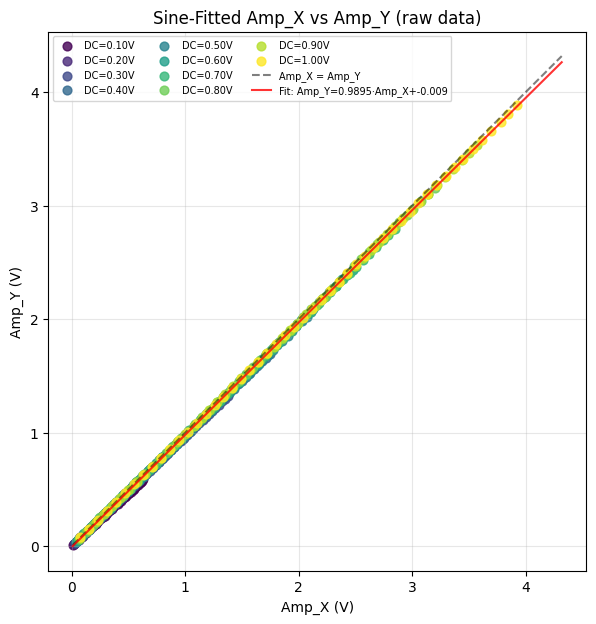

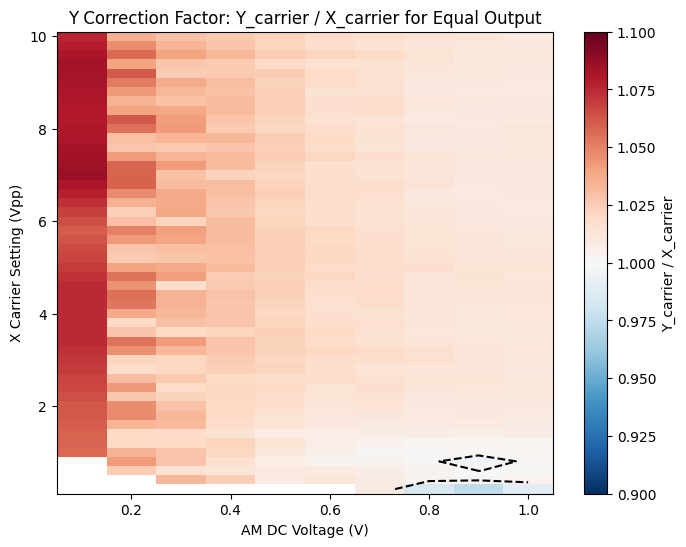

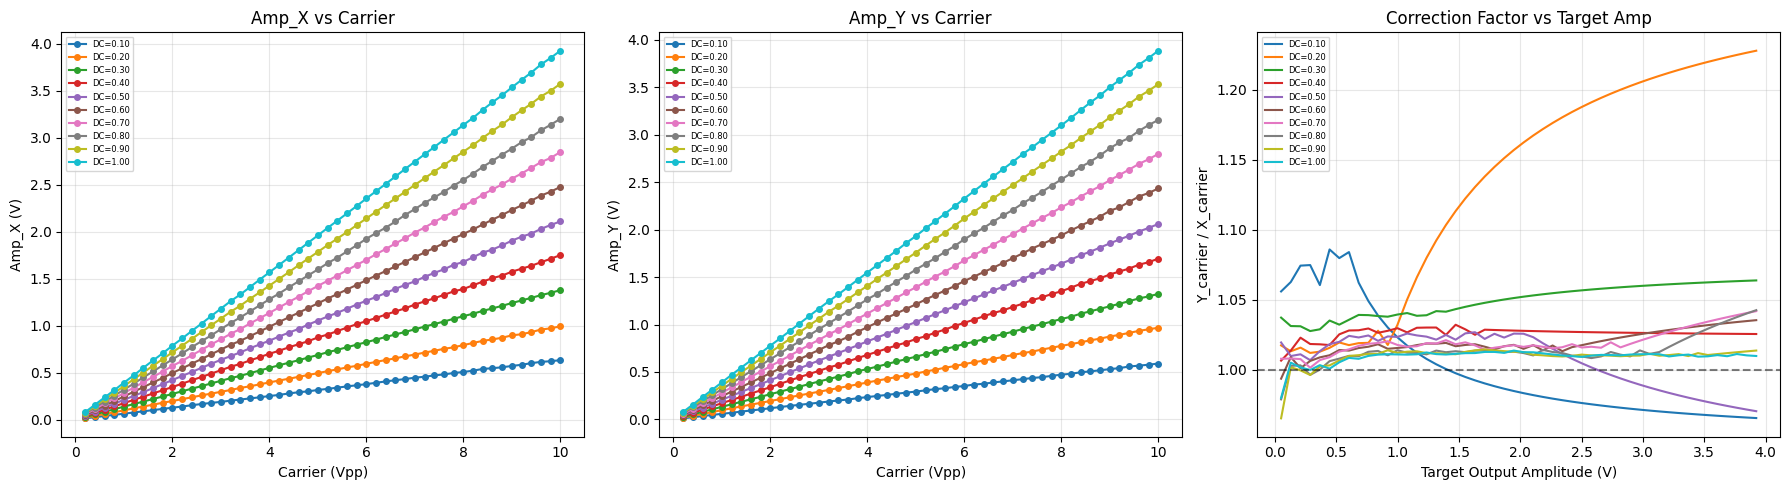


分析结果已保存: d:\Code\exp_agent\data\XY_Output_Verification\0521_1814_scope_vpp\results
  修正因子均值 = 1.028843 ± 0.047143
  校准函数已导出: d:\Code\exp_agent\data\XY_Output_Verification\0521_1814_scope_vpp\results\calibration_function.py

✅ 校准分析完成!
  使用方式: from calibration_function import calibrate_y
           y_setting = calibrate_y(0.5, 5.0)  # DC=0.5V, X设5Vpp → Y应设?


In [28]:
# ============================================================
# 结果分析: 正弦拟合提取幅值 + Y 通道校准
# ============================================================
# 目标: 对任意 (DC 电压, X 载波设置), 给出 Y 应设置的载波幅度,
#       使两个通道的实际输出幅值相等。

from scipy.interpolate import LinearNDInterpolator, interp1d

# 正弦拟合模型: A * sin(2π·f·t + φ) + offset
def sine_model(t, A, f, phi, offset):
    return A * np.sin(2 * np.pi * f * t + phi) + offset

# 加载时间轴
TIME_AXIS = np.load(raw_dir / "time_axis.npy")

# 加载扫描参数
sp = np.load(raw_dir / "scan_params.npz")
DC_VALS = sp["dc_voltages"]
CARRIER_AMPS = sp["carrier_amplitudes"]
n_dc, n_amp = len(DC_VALS), len(CARRIER_AMPS)

# ── 1. 正弦拟合, 得到每个 (DC, Carrier) → 实际幅值 ──
amp_x = np.full((n_dc, n_amp), np.nan)
amp_y = np.full_like(amp_x, np.nan)

print(f"对 {n_dc}×{n_amp}={n_dc*n_amp} 个点做正弦拟合...")

for i_dc in range(n_dc):
    for i_amp in range(n_amp):
        file_tag = f"D{i_dc:02d}_A{i_amp:02d}"
        path_x = raw_dir / f"waveform_x_{file_tag}.npy"
        path_y = raw_dir / f"waveform_y_{file_tag}.npy"
        if not path_x.exists() or not path_y.exists():
            continue

        x_wave = np.load(path_x)
        y_wave = np.load(path_y)
        t = TIME_AXIS[:len(x_wave)]

        try:
            A0_x = (np.max(x_wave) - np.min(x_wave)) / 2
            off0_x = (np.max(x_wave) + np.min(x_wave)) / 2
            popt_x, _ = curve_fit(sine_model, t, x_wave,
                                  p0=[A0_x, XY_CARRIER_FREQ, 0, off0_x],
                                  maxfev=10000)
            amp_x[i_dc, i_amp] = abs(popt_x[0])

            A0_y = (np.max(y_wave) - np.min(y_wave)) / 2
            off0_y = (np.max(y_wave) + np.min(y_wave)) / 2
            popt_y, _ = curve_fit(sine_model, t, y_wave,
                                  p0=[A0_y, XY_CARRIER_FREQ, 0, off0_y],
                                  maxfev=10000)
            amp_y[i_dc, i_amp] = abs(popt_y[0])
        except Exception as e:
            print(f"  拟合失败 {file_tag}: {e}")

n_fitted = np.sum(~np.isnan(amp_x))
print(f"拟合完成: {n_fitted}/{n_dc*n_amp} 点成功")

# ── 2. 每个 DC 下, 插值求反向映射: 目标幅值 → 所需载波设置 ──
# 在更密的幅值网格上做插值, 便于后续查表
target_amp_grid = np.linspace(
    max(np.nanmin(amp_x), 0.05), np.nanmax(amp_x), 50
)

carrier_for_x = np.full((n_dc, len(target_amp_grid)), np.nan)  # X 的目标载波
carrier_for_y = np.full_like(carrier_for_x, np.nan)             # Y 等幅所需的载波
correction_factor = np.full_like(carrier_for_x, np.nan)         # Y_carr / X_carr

for i_dc in range(n_dc):
    mask = ~np.isnan(amp_x[i_dc, :])
    if np.sum(mask) < 3:
        continue
    # X 通道: amp_x → carrier 的插值 (单调递增, 直接插)
    interp_x = interp1d(amp_x[i_dc, :][mask], CARRIER_AMPS[mask],
                        kind="linear", fill_value="extrapolate")
    carrier_x_i = interp_x(target_amp_grid)
    carrier_for_x[i_dc, :] = carrier_x_i

    # Y 通道: amp_y → carrier 的插值
    mask_y = ~np.isnan(amp_y[i_dc, :])
    if np.sum(mask_y) < 3:
        continue
    interp_y = interp1d(amp_y[i_dc, :][mask_y], CARRIER_AMPS[mask_y],
                        kind="linear", fill_value="extrapolate")
    # 要使 Y 的实际幅值 = X 的实际幅值 = target_amp_grid
    carrier_for_y[i_dc, :] = interp_y(target_amp_grid)

    # 修正因子: Y_carrier / X_carrier (等幅输出时)
    valid = (carrier_x_i > 0) & (carrier_for_y[i_dc, :] > 0)
    correction_factor[i_dc, valid] = (
        carrier_for_y[i_dc, valid] / carrier_x_i[valid]
    )

# ── 3. 构建全局校准插值器: f(DC, X_carrier) → Y_carrier ──
# 用 (DC, X_carrier) → Y_carrier 的散点构建 2D 插值
points = []   # (DC, X_carrier)
values = []   # Y_carrier
for i_dc, dc_v in enumerate(DC_VALS):
    mask_pt = ~np.isnan(carrier_for_y[i_dc, :])
    if np.sum(mask_pt) < 2:
        continue
    for j in np.where(mask_pt)[0]:
        points.append([dc_v, carrier_for_x[i_dc, j]])
        values.append(carrier_for_y[i_dc, j])

points = np.array(points)
values = np.array(values)
calib_interp = LinearNDInterpolator(points, values)

print(f"\n校准插值器已构建: 从 {len(values)} 个散点")

# ── 4. 构建修正因子插值器: f(DC, X_carrier) → correction ──
# 方便直接查修正倍数
corr_points = []
corr_values = []
for i_dc, dc_v in enumerate(DC_VALS):
    mask_pt = ~np.isnan(correction_factor[i_dc, :])
    if np.sum(mask_pt) < 2:
        continue
    for j in np.where(mask_pt)[0]:
        corr_points.append([dc_v, carrier_for_x[i_dc, j]])
        corr_values.append(correction_factor[i_dc, j])

corr_points = np.array(corr_points)
corr_values_arr = np.array(corr_values)
correction_interp = LinearNDInterpolator(corr_points, corr_values_arr)

# ── 5. 可视化 ──
# 5a. 原始 Amp_X vs Amp_Y 散点 + 对角线
fig1, ax1 = plt.subplots(figsize=(7, 7))
colors = plt.cm.viridis(np.linspace(0, 1, n_dc))
for i_dc, dc_v in enumerate(DC_VALS):
    mask = ~np.isnan(amp_x[i_dc, :]) & ~np.isnan(amp_y[i_dc, :])
    if np.sum(mask) == 0:
        continue
    ax1.scatter(amp_x[i_dc, :][mask], amp_y[i_dc, :][mask],
                color=colors[i_dc], s=40, alpha=0.8,
                label=f"DC={dc_v:.2f}V")

v_min = min(np.nanmin(amp_x), np.nanmin(amp_y)) * 0.9
v_max = max(np.nanmax(amp_x), np.nanmax(amp_y)) * 1.1
ax1.plot([v_min, v_max], [v_min, v_max], "k--", alpha=0.5, label="Amp_X = Amp_Y")
ax1.set_xlabel("Amp_X (V)"); ax1.set_ylabel("Amp_Y (V)")
ax1.set_title("Sine-Fitted Amp_X vs Amp_Y (raw data)")
ax1.legend(fontsize=7, ncol=2); ax1.grid(True, alpha=0.3); ax1.set_aspect("equal")

all_x = amp_x.flatten(); all_y = amp_y.flatten()
valid = ~np.isnan(all_x) & ~np.isnan(all_y)
if np.sum(valid) >= 5:
    k_all, b_all = np.polyfit(all_x[valid], all_y[valid], 1)
    ax1.plot([v_min, v_max], k_all * np.array([v_min, v_max]) + b_all,
             "r-", lw=1.5, alpha=0.8,
             label=f"Fit: Amp_Y={k_all:.4f}·Amp_X+{b_all:.3f}")
    ax1.legend(fontsize=7, ncol=3)

display(fig1); fig1.savefig(results_dir / "amp_x_vs_y.png", dpi=150); plt.close(fig1)

# 5b. 修正因子热力图: correction(DC, X_carrier) — 关键图!
DC_MESH, CARR_MESH = np.meshgrid(DC_VALS, CARRIER_AMPS)
corr_on_mesh = correction_interp(DC_MESH, CARR_MESH)

fig2, ax2 = plt.subplots(figsize=(8, 6))
im = ax2.pcolormesh(DC_VALS, CARRIER_AMPS, corr_on_mesh,
                    cmap="RdBu_r", vmin=0.9, vmax=1.1, shading="auto")
ax2.set_xlabel("AM DC Voltage (V)"); ax2.set_ylabel("X Carrier Setting (Vpp)")
ax2.set_title("Y Correction Factor: Y_carrier / X_carrier for Equal Output")
fig2.colorbar(im, ax=ax2, label="Y_carrier / X_carrier")
# 标出 1.0 等值线
ax2.contour(DC_VALS, CARRIER_AMPS, corr_on_mesh, levels=[1.0],
            colors="k", linewidths=1.5, linestyles="--")
display(fig2); fig2.savefig(results_dir / "correction_heatmap.png", dpi=150); plt.close(fig2)

# 5c. 每个 DC 下的实际幅值 vs 载波设置
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
for i_dc, dc_v in enumerate(DC_VALS):
    axes3[0].plot(CARRIER_AMPS, amp_x[i_dc, :], "o-", ms=4, label=f"DC={dc_v:.2f}")
    axes3[1].plot(CARRIER_AMPS, amp_y[i_dc, :], "o-", ms=4, label=f"DC={dc_v:.2f}")
    axes3[2].plot(target_amp_grid, correction_factor[i_dc, :], "-", lw=1.5,
                  label=f"DC={dc_v:.2f}")

axes3[0].set_xlabel("Carrier (Vpp)"); axes3[0].set_ylabel("Amp_X (V)")
axes3[0].set_title("Amp_X vs Carrier"); axes3[0].legend(fontsize=6); axes3[0].grid(alpha=0.3)
axes3[1].set_xlabel("Carrier (Vpp)"); axes3[1].set_ylabel("Amp_Y (V)")
axes3[1].set_title("Amp_Y vs Carrier"); axes3[1].legend(fontsize=6); axes3[1].grid(alpha=0.3)
axes3[2].axhline(y=1.0, color="k", ls="--", alpha=0.5)
axes3[2].set_xlabel("Target Output Amplitude (V)"); axes3[2].set_ylabel("Y_carrier / X_carrier")
axes3[2].set_title("Correction Factor vs Target Amp"); axes3[2].legend(fontsize=6); axes3[2].grid(alpha=0.3)
plt.tight_layout()
display(fig3); fig3.savefig(results_dir / "calibration_curves.png", dpi=150); plt.close(fig3)

# ── 6. 保存校准结果 ──
np.savez(results_dir / "calibration.npz",
         dc_voltages=DC_VALS,
         carrier_amplitudes=CARRIER_AMPS,
         target_amp_grid=target_amp_grid,
         carrier_for_x=carrier_for_x,
         carrier_for_y=carrier_for_y,
         correction_factor=correction_factor,
         calib_points=points, calib_values=values)

# 输出用户可用的校准函数代码片段
calib_code = f'''# Y 通道校准函数 (可直接复制使用)
# 用法: y_carrier = calibrate_y(dc_voltage, x_carrier_setting)
import numpy as np
from scipy.interpolate import LinearNDInterpolator

_calib_points = np.array({points.tolist()})
_calib_values = np.array({values.tolist()})
_calib = LinearNDInterpolator(_calib_points, _calib_values)

def calibrate_y(dc_v, x_carrier):
    \"\"\"返回 Y 应设置的载波幅度(Vpp), 使两通道输出幅值相等.\"\"\"
    return float(_calib(dc_v, x_carrier))
'''
with open(results_dir / "calibration_function.py", "w", encoding="utf-8") as f:
    f.write(calib_code)

# ── 7. 保存汇总 ──
analysis = {
    "experiment_type": EXPERIMENT_TYPE,
    "method": "sine_fit_equal_output_calibration",
    "carrier_freq_Hz": XY_CARRIER_FREQ,
    "description": "对每个(DC, X_carrier), 插值得到使 Y 等幅输出的 Y_carrier 设置",
    "n_fitted": int(n_fitted),
    "correction_factor_stats": {
        "mean": float(np.nanmean(corr_values_arr)),
        "std": float(np.nanstd(corr_values_arr)),
        "min": float(np.nanmin(corr_values_arr)),
        "max": float(np.nanmax(corr_values_arr)),
    },
    "usage": "calibrate_y(dc_v, x_carrier) → Y应设载波幅度(Vpp)",
}
with open(results_dir / "analysis.yaml", "w", encoding="utf-8") as f:
    yaml.dump(analysis, f, default_flow_style=False, allow_unicode=True)

print(f"\n分析结果已保存: {results_dir}")
print(f"  修正因子均值 = {np.nanmean(corr_values_arr):.6f} ± {np.nanstd(corr_values_arr):.6f}")
print(f"  校准函数已导出: {results_dir / 'calibration_function.py'}")
print(f"\n✅ 校准分析完成!")
print(f"  使用方式: from calibration_function import calibrate_y")
print(f"           y_setting = calibrate_y(0.5, 5.0)  # DC=0.5V, X设5Vpp → Y应设?")

<a id='cleanup'></a>
## 4. 安全关闭

In [ ]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

# 仅断开连接，不改变任何输出状态
for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")